In [4]:
import soundfile as sf
import numpy as np

# Load a single RIR
rir, sr = sf.read("single_channel_ir_1/Apartments/Apartments_idx_0/S000_R000_hybrid_IR.wav")
print(f"Sample rate: {sr} Hz, Length: {len(rir)/sr:.3f}s")

Sample rate: 22050 Hz, Length: 1.000s


In [6]:
import json

with open("metadata/Apartments/Apartments_idx_0/S000_R000.json") as f:
    meta = json.load(f)

source_pos = meta["src_loc"]   # [x, y, z]
receiver_pos = meta["rec_loc"]  # [x, y, z]

In [30]:
import soundfile as sf
from scipy.signal import fftconvolve

# Load dry audio and RIR
audio, sr_audio = sf.read("clap22.wav")


print(sr_audio, len(audio))
rir, sr_rir = sf.read("single_channel_ir_1/Apartments/Apartments_idx_0/S000_R000_hybrid_IR.wav")
print(sr_rir, len(rir))


print(audio.shape, rir.shape)
if audio.ndim == 2:
    audio = audio.mean(axis=1)

# Convolve to get reverberant audio
reverberant = fftconvolve(audio, rir, mode='full')[:len(audio)]
sf.write("reverberant_output.wav", reverberant, sr_audio)

22050 76734
22050 22050
(76734, 2) (22050,)


In [8]:
import os
import torch
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from IPython.display import Audio, display

from train import (
    load_dataset,
    add_room_context_features,
    normalize_room_context,
)
from models.rir_network import RIRNetwork


def add_pair_geometry_features_local(df, speed_of_sound=343.0):
    out_df = df.copy()
    src = out_df[["src_x", "src_y", "src_z"]].to_numpy(dtype=np.float32)
    rec = out_df[["rec_x", "rec_y", "rec_z"]].to_numpy(dtype=np.float32)

    distances = np.linalg.norm(src - rec, axis=1)
    delays = distances / max(speed_of_sound, 1e-6)

    out_df["ctx_pair_distance_m"] = distances.astype(np.float32)
    out_df["ctx_pair_delay_s"] = delays.astype(np.float32)
    out_df["ctx_pair_inv_distance"] = (1.0 / np.maximum(distances, 1e-6)).astype(np.float32)

    return out_df, ["ctx_pair_distance_m", "ctx_pair_delay_s", "ctx_pair_inv_distance"]


# Point to your newly trained checkpoint
checkpoint_path = "checkpoints/timing_causality_full_dataset/best_model.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu")
args = checkpoint["args"]
room_context_columns = checkpoint.get("room_context_columns", [])

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Checkpoint: {checkpoint_path}")
print(f"Room context dim from checkpoint: {len(room_context_columns)}")

Device: cuda
Checkpoint: checkpoints/timing_causality_full_dataset/best_model.pt
Room context dim from checkpoint: 23


In [9]:
# Rebuild the same split used in training so context normalization is consistent
train_df, val_df, test_df = load_dataset(
    args["ir_base"],
    args["meta_base"],
    seed=args["seed"],
    max_rooms=args["max_rooms"],
    max_samples=args["max_samples"],
)

# Build context features exactly like training, but keep checkpoint column order authoritative.
if args.get("use_room_context", False):
    train_df, material_cols = add_room_context_features(
        train_df,
        simulation_info_base=args["simulation_info_base"],
        material_library_dir=args["material_library_dir"],
    )
    val_df, _ = add_room_context_features(
        val_df,
        simulation_info_base=args["simulation_info_base"],
        material_library_dir=args["material_library_dir"],
    )
    test_df, _ = add_room_context_features(
        test_df,
        simulation_info_base=args["simulation_info_base"],
        material_library_dir=args["material_library_dir"],
    )
    train_df, val_df, test_df = normalize_room_context(train_df, val_df, test_df, material_cols)

if args.get("use_pair_geometry_features", False):
    train_df, pair_cols = add_pair_geometry_features_local(
        train_df,
        speed_of_sound=args.get("speed_of_sound", 343.0),
    )
    val_df, _ = add_pair_geometry_features_local(
        val_df,
        speed_of_sound=args.get("speed_of_sound", 343.0),
    )
    test_df, _ = add_pair_geometry_features_local(
        test_df,
        speed_of_sound=args.get("speed_of_sound", 343.0),
    )
    train_df, val_df, test_df = normalize_room_context(train_df, val_df, test_df, pair_cols)

# Ensure all checkpoint context columns exist and are in exact order expected by the trained model.
for col in room_context_columns:
    if col not in train_df.columns:
        train_df[col] = 0.0
        val_df[col] = 0.0
        test_df[col] = 0.0

# Pick one test sample to compare predicted vs ground truth
sample = test_df.iloc[0]
print("Selected sample:")
print(sample[["room_type", "room_id", "stem"]])

# Load model
model = RIRNetwork(
    input_dim=6,
    output_dim=args["output_dim"],
    hidden_dim=args["hidden_dim"],
    num_hidden_layers=args["num_hidden_layers"],
    num_frequencies=args["num_frequencies"],
    room_context_dim=len(room_context_columns),
)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

# Build model inputs
coords = torch.tensor([
    sample["src_x"], sample["src_y"], sample["src_z"],
    sample["rec_x"], sample["rec_y"], sample["rec_z"],
], dtype=torch.float32).unsqueeze(0).to(device)

if len(room_context_columns) > 0:
    room_ctx = torch.tensor(sample[room_context_columns].to_numpy(dtype=np.float32), dtype=torch.float32).unsqueeze(0).to(device)
else:
    room_ctx = None

with torch.no_grad():
    pred_rir = model(coords, room_context=room_ctx).squeeze(0).cpu().numpy()

# Load ground-truth RIR
gt_rir, gt_sr = sf.read(sample["rir_path"])
if gt_rir.ndim > 1:
    gt_rir = gt_rir[:, 0]
max_val = np.abs(gt_rir).max()
if max_val > 0:
    gt_rir = gt_rir / max_val

# Match lengths for fair comparison
L = min(len(pred_rir), len(gt_rir))
pred_rir = pred_rir[:L]
gt_rir = gt_rir[:L]

mse = float(np.mean((pred_rir - gt_rir) ** 2))
mae = float(np.mean(np.abs(pred_rir - gt_rir)))
corr = float(np.corrcoef(pred_rir, gt_rir)[0, 1]) if np.std(pred_rir) > 0 and np.std(gt_rir) > 0 else float("nan")

print(f"Length compared: {L} samples")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"Correlation: {corr:.4f}")

os.makedirs("predictions", exist_ok=True)
pred_rir_path = "predictions/pred_rir.wav"
gt_rir_path = "predictions/gt_rir.wav"

sf.write(pred_rir_path, pred_rir, gt_sr)
sf.write(gt_rir_path, gt_rir, gt_sr)

print(f"Saved predicted RIR: {pred_rir_path}")
print(f"Saved ground-truth RIR: {gt_rir_path}")

Rooms  — train: 208, val: 26, test: 26
Samples — train: 227932, val: 20650, test: 27702
Split sizes -> train: 227932, val: 20650, test: 27702
Selected sample from test split:
room_type           MeetingRoom
room_id      MeetingRoom_idx_23
stem                  S002_R003
Name: 0, dtype: object
Length compared: 16000 samples
MSE: 0.001086
MAE: 0.011062
Correlation: 0.0068
Saved predicted RIR: predictions/pred_rir.wav
Saved ground-truth RIR: predictions/gt_rir.wav


Saved predicted reverberant audio: predictions/reverb_pred.wav
Saved GT reverberant audio: predictions/reverb_gt.wav


Saved predicted reverberant audio: predictions/reverb_pred.wav
Saved GT reverberant audio: predictions/reverb_gt.wav


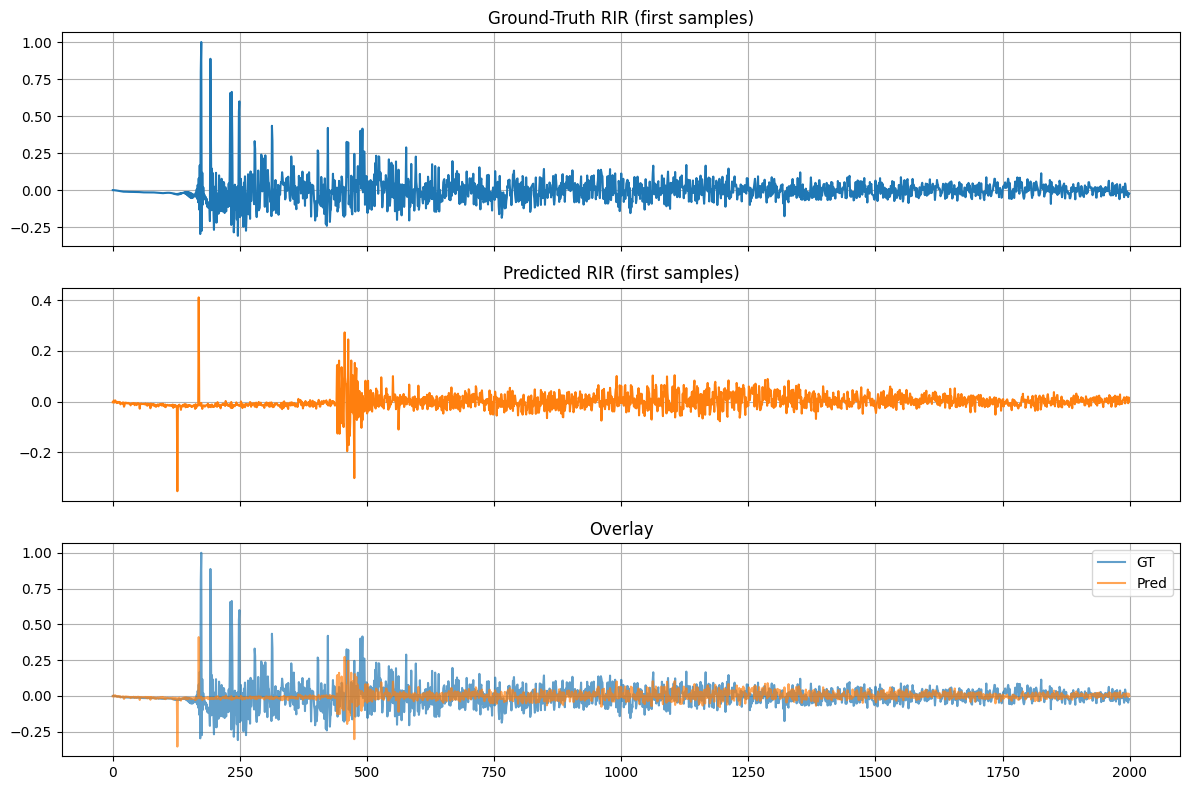


Listen here:
1) Predicted RIR impulse


2) Ground-truth RIR impulse


3) Predicted reverberant signal


4) Ground-truth reverberant signal


In [10]:
# Convolve dry audio with predicted and GT RIR so you can listen to the difference
# Uses clap22.wav if available; otherwise generates a short synthetic click signal.
dry_audio_path = "clap22.wav"
if os.path.exists(dry_audio_path):
    audio, sr_audio = sf.read(dry_audio_path)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
else:
    sr_audio = gt_sr
    duration_sec = 1.0
    n = int(sr_audio * duration_sec)
    audio = np.zeros(n, dtype=np.float32)
    # Sparse clicks approximate transient excitation and are easy to hear after convolution.
    click_positions = [int(0.05 * sr_audio), int(0.2 * sr_audio), int(0.45 * sr_audio)]
    for idx in click_positions:
        if idx < n:
            audio[idx] = 1.0
    print("clap22.wav not found; using synthetic click signal")

if sr_audio != gt_sr:
    print(f"Warning: dry audio SR ({sr_audio}) != RIR SR ({gt_sr}); using RIR SR for output files")

reverb_pred = fftconvolve(audio, pred_rir, mode="full")[: len(audio)]
reverb_gt = fftconvolve(audio, gt_rir, mode="full")[: len(audio)]

pred_audio_path = "predictions/reverb_pred.wav"
gt_audio_path = "predictions/reverb_gt.wav"

sf.write(pred_audio_path, reverb_pred, gt_sr)
sf.write(gt_audio_path, reverb_gt, gt_sr)

print(f"Saved predicted reverberant audio: {pred_audio_path}")
print(f"Saved GT reverberant audio: {gt_audio_path}")

# Waveform comparison plot (first 2000 samples)
N = min(2000, L)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(gt_rir[:N], label="GT RIR")
axes[0].set_title("Ground-Truth RIR (first samples)")
axes[0].grid(True)

axes[1].plot(pred_rir[:N], label="Pred RIR", color="tab:orange")
axes[1].set_title("Predicted RIR (first samples)")
axes[1].grid(True)

axes[2].plot(gt_rir[:N], label="GT", alpha=0.7)
axes[2].plot(pred_rir[:N], label="Pred", alpha=0.7)
axes[2].set_title("Overlay")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("\nListen here:")
print("1) Predicted RIR impulse")
display(Audio(pred_rir, rate=gt_sr))
print("2) Ground-truth RIR impulse")
display(Audio(gt_rir, rate=gt_sr))
print("3) Predicted reverberant signal")
display(Audio(reverb_pred, rate=gt_sr))
print("4) Ground-truth reverberant signal")
display(Audio(reverb_gt, rate=gt_sr))